In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [79]:
df = pd.read_csv("../data/preprocessed/fakenews_preprocessed.csv")

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62126 entries, 0 to 62125
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  62126 non-null  object 
 1   text                   62126 non-null  object 
 2   subject                62126 non-null  object 
 3   real                   62126 non-null  int64  
 4   clean_title            62126 non-null  object 
 5   clean_text             62126 non-null  object 
 6   text_len               62126 non-null  int64  
 7   avg_word_len           61679 non-null  float64
 8   num_sents              62126 non-null  int64  
 9   polarity               62126 non-null  float64
 10  subjectivity           62126 non-null  float64
 11  prep_text              61678 non-null  object 
 12  sentence_count         62126 non-null  int64  
 13  grade_level            60671 non-null  float64
 14  flesch_ease            60671 non-null  float64
 15  fl

In [81]:
df.head()

,title,text,subject,real,clean_title,clean_text,text_len,avg_word_len,num_sents,polarity,...,flesch_grade,gunning_fog,smog,ari,coleman_liau,flesch_interpretation,punct_count,word_count,punct_ratio,entity_count
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,0,donald trump sends out embarrassing new ear s...,donald trump just couldn t wish all americans ...,503,4.337972,1,-0.014387,...,8.726552,10.363443,11.812371,9.679789,9.062195,Standard - 8th-9th grade,121,495,0.244444,28
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,0,drunk bragging trump staffer started russian ...,house intelligence committee chairman devin nu...,309,4.951456,1,0.033536,...,10.942923,13.072860,12.745085,11.595993,11.947541,Difficult - College,39,305,0.127869,24
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,0,sheriff david clarke becomes an internet joke...,on frida it was revealed that former milwaukee...,598,4.658863,1,-0.020018,...,8.616870,10.647496,11.645159,10.957494,10.928843,Standard - 8th-9th grade,148,580,0.255172,37
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,0,trump is so obsessed he even has obama s name...,on christmas da donald trump announced that he...,458,4.665939,1,-0.026923,...,9.966244,12.498177,13.023867,11.788649,11.285261,Fairly Difficult - 10th-12th grade,118,444,0.265766,26
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,0,pope francis just called out donald trump dur...,pope francis used his annual christmas da mess...,425,4.322353,1,-0.069810,...,9.766190,12.209524,11.505630,10.522929,8.655714,Standard - 8th-9th grade,40,420,0.095238,24


In [82]:
df = df.dropna(subset=["prep_text"]).reset_index(drop=True)

In [83]:
df.duplicated(subset="prep_text").sum()

np.int64(9015)

In [84]:
import re

def clean_text(t):
    t = t.lower()
    t = re.sub(r"\s+", " ", t)
    t = re.sub(r"[^\w\s]", "", t)
    return t.strip()

df["text_clean"] = df["prep_text"].apply(clean_text)
df = df.drop_duplicates(subset="text_clean")

In [85]:
df = df.drop_duplicates(subset="text").reset_index(drop=True)

In [87]:
df = df.sort_values(by="text_clean")

# vectorize smaller chunks
vectorizer = TfidfVectorizer(stop_words='english', max_features=30000)

to_remove = set()
chunk_size = 2000

for start in range(0, len(df), chunk_size):
    end = min(start + chunk_size, len(df))
    chunk = df.iloc[start:end]

    X_chunk = vectorizer.fit_transform(chunk["text_clean"])
    sim = cosine_similarity(X_chunk)

    for i in range(sim.shape[0]):
        for j in range(i+1, sim.shape[0]):
            if sim[i, j] > 0.95:
                to_remove.add(chunk.index[j])

df = df.drop(list(to_remove)).reset_index(drop=True)


In [88]:
df.duplicated(subset="prep_text").sum()

np.int64(0)

In [89]:
X = df["prep_text"].values
y = df["real"].values

In [90]:
X.shape

(51860,)

In [91]:
y.shape

(51860,)

In [92]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [93]:
def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='macro'),
        "Recall": recall_score(y_true, y_pred, average='macro'),
        "F1": f1_score(y_true, y_pred, average='macro')
    }

In [94]:
results = []

# TF-IDF

In [95]:
tfidf = TfidfVectorizer(binary=True)

In [96]:
X_train = tfidf.fit_transform(X_train)
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6514253 stored elements and shape (41488, 165692)>

In [97]:
X_val = tfidf.transform(X_val)
X_val

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1612160 stored elements and shape (10372, 165692)>

# Logistic Regression

In [98]:
model_lr = LogisticRegression(max_iter=2000, random_state=42)

In [99]:
model_lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [100]:
y_pred = model_lr.predict(X_val)

In [101]:
metrics_lr = evaluate_model("Logistic Regression", y_val, y_pred)
metrics_lr

{'Model': 'Logistic Regression',
 'Accuracy': 0.9836097184728114,
 'Precision': 0.9855511544850273,
 'Recall': 0.9777413458656,
 'F1': 0.9814899038072111}

In [102]:
results.append(metrics_lr)

# Ridge Regression

In [103]:
model_rr = RidgeClassifier()

In [104]:
model_rr.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,class_weight,None
,solver,'auto'
,positive,False
,random_state,None


In [105]:
y_pred_rr = model_rr.predict(X_val)

In [106]:
metrics_rr = evaluate_model("Ridge Classifier", y_val, y_pred_rr)
metrics_rr

{'Model': 'Ridge Classifier',
 'Accuracy': 0.9889124566139607,
 'Precision': 0.99092809141922,
 'Recall': 0.9842844678577386,
 'F1': 0.9874940938536394}

In [107]:
results.append(metrics_rr)

# Random Forest Classifier

In [108]:
model_rf = RandomForestClassifier(n_estimators=200, random_state=42)

In [109]:
model_rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [110]:
y_pred_rf = model_rf.predict(X_val)

In [111]:
metrics_rf = evaluate_model("Random Forest Classifier", y_val, y_pred_rf)
metrics_rf

{'Model': 'Random Forest Classifier',
 'Accuracy': 0.9670266101041265,
 'Precision': 0.9748296352717645,
 'Recall': 0.952079760059282,
 'F1': 0.962188870939952}

In [112]:
results.append(metrics_rf)

# Gradient Boosting

In [113]:
model_gbc = GradientBoostingClassifier(random_state=42)

In [114]:
model_gbc.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [115]:
y_pred_gbc = model_gbc.predict(X_val)

In [116]:
metrics_gbc = evaluate_model("Gradient Boosting Classifier", y_val, y_pred_gbc)
metrics_gbc

{'Model': 'Gradient Boosting Classifier',
 'Accuracy': 0.9634593135364443,
 'Precision': 0.9608892286574471,
 'Recall': 0.9569708650793374,
 'F1': 0.9588867717004956}

In [117]:
results.append(metrics_gbc)

# XGBoost

In [118]:
model_xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_estimators=200,
    tree_method="hist"
)

In [119]:
model_xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [120]:
y_pred_xgb = model_xgb.predict(X_val)

In [121]:
metrics_xgb = evaluate_model("XGBoost Classifier", y_val, y_pred_xgb)
metrics_xgb

{'Model': 'XGBoost Classifier',
 'Accuracy': 0.9852487466255303,
 'Precision': 0.9858013570159598,
 'Recall': 0.9811003276205941,
 'F1': 0.9833932156282195}

In [122]:
results.append(metrics_xgb)

# Visualize the results

In [123]:
df_results = pd.DataFrame(results)

In [124]:
df_results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.983610,0.985551,0.977741,0.981490
1,Ridge Classifier,0.988912,0.990928,0.984284,0.987494
2,Random Forest Classifier,0.967027,0.974830,0.952080,0.962189
3,Gradient Boosting Classifier,0.963459,0.960889,0.956971,0.958887
4,XGBoost Classifier,0.985249,0.985801,0.981100,0.983393


In [126]:
from sklearn.utils import shuffle
X_shuf, y_shuf = shuffle(X_train, y_train, random_state=42)

model_lr.fit(X_shuf, y_shuf)
model_lr.score(X_val, y_val)

0.9836097184728114

In [128]:
def predict_news(text, vectorizer, model):
    # Clean the text the same way you preprocessed your dataset
    text_clean = text.lower().strip()

    # Vectorize
    text_tfidf = vectorizer.transform([text_clean])

    # Predict class
    pred = model.predict(text_tfidf)[0]

    # Get probability (if supported)
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(text_tfidf)[0]
        return pred, proba
    else:
        return pred, None


In [129]:
text = """
Margaret Brennan and John Dickerson of CBS News claimed that “the president of the United States has nothing to do with the price of bacon,” “or eggs,” “or gas,” “or any of it.”

In fact, presidents impact the prices of virtually everything through federal deficits that spur inflation, regulations that prohibit the use of cost-effective production methods and resources, price and wage controls, trade deals, tariffs, and more.
"""

text2 = """
Reporting on the first assassination attempt against Donald Trump, George Stephanopoulos and Martha Raddatz of ABC News claimed that Trump “contributed” to “violent rhetoric” because he said “it’s going to be a bloodbath” if “I don’t get elected.”

In fact, Trump didn’t use the term “bloodbath” as a call to violence but to describe the effects of Biden’s policies, especially on the auto industry.
"""


text3 = """
MSNBC’s Lawrence O’Donnell claimed that “no one in our lifetimes has saved more lives” than Anthony Fauci.

In fact, Fauci may have killed more people than anyone in our lifetimes:

First, Fauci led the federal agency that funded gain-of-function research on bat coronaviruses at the Wuhan Institute of Virology and then lied about it to Congress.
Second, Fauci greatly overstated the Covid-19 death rate, prompting mass hysteria and lockdowns that already have or ultimately will shorten the lives of millions of people.
Third, Fauci spread the hoax that C-19 was a “pandemic of the unvaccinated” when more than half of all Covid deaths were among the fully vaccinated.
"""

pred, proba = predict_news(text, tfidf, model_lr)

print("Prediction:", "REAL" if pred == 1 else "FAKE")

if proba is not None:
    print("Probabilities:", proba)


Prediction: FAKE
Probabilities: [0.80017023 0.19982977]


In [130]:
pred, proba = predict_news(text2, tfidf, model_lr)

print("Prediction:", "REAL" if pred == 1 else "FAKE")

if proba is not None:
    print("Probabilities:", proba)

Prediction: FAKE
Probabilities: [0.89837265 0.10162735]


In [131]:
pred, proba = predict_news(text3, tfidf, model_lr)

print("Prediction:", "REAL" if pred == 1 else "FAKE")

if proba is not None:
    print("Probabilities:", proba)

Prediction: FAKE
Probabilities: [0.71876607 0.28123393]


In [125]:
df_melt = df_results.melt(id_vars="Model", var_name="Metric", value_name="Score")

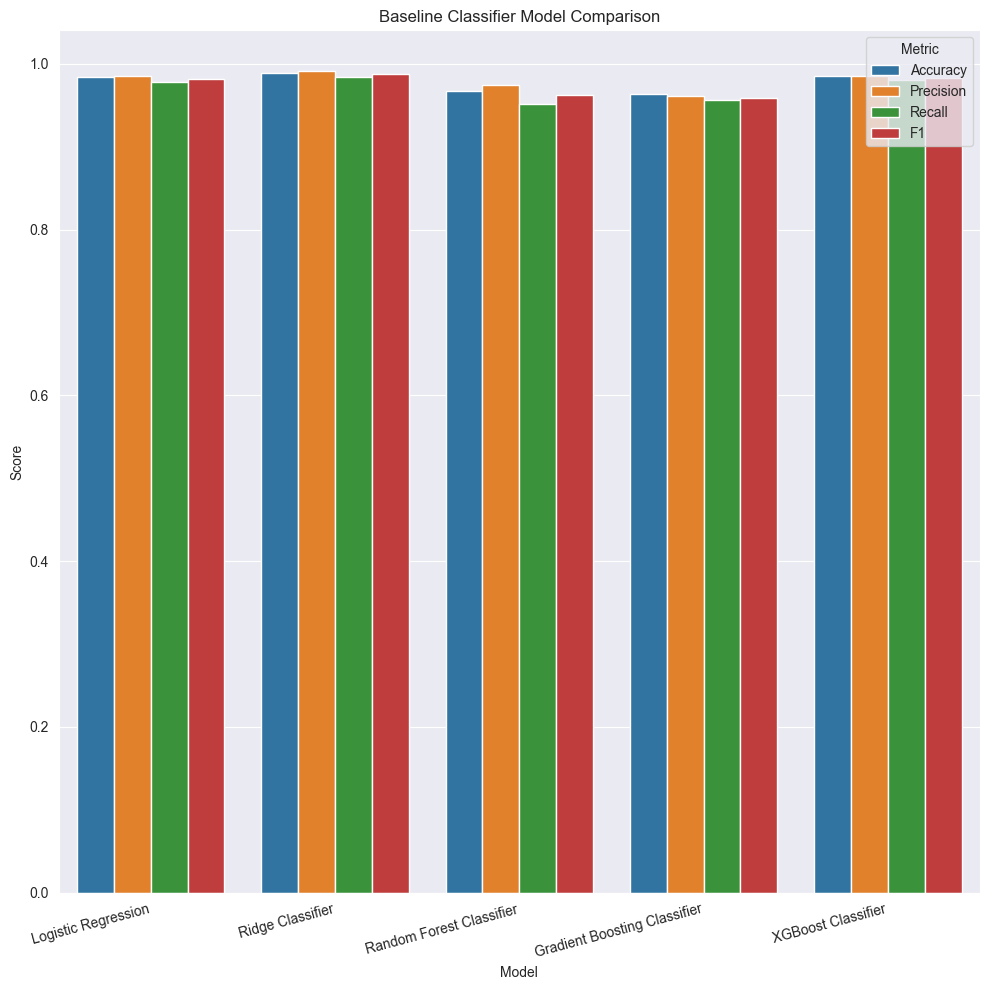

In [127]:
plt.figure(figsize = (10,10))
sns.barplot(data=df_melt, x="Model", y="Score", hue="Metric")
plt.title("Baseline Classifier Model Comparison")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("../images/classicModels.png")
plt.show()

In [66]:
from sklearn.metrics import confusion_matrix, classification_report

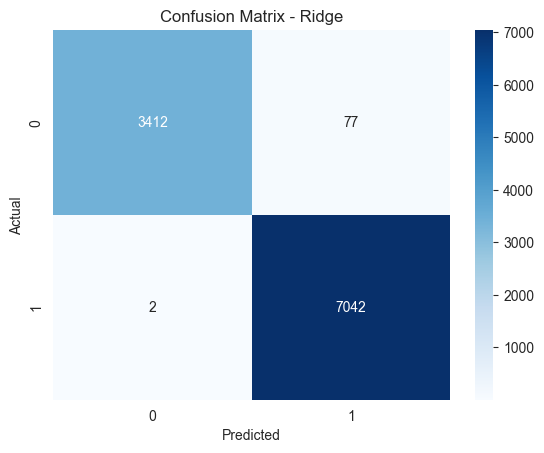


Ridge:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99      3489
           1       0.99      1.00      0.99      7044

    accuracy                           0.99     10533
   macro avg       0.99      0.99      0.99     10533
weighted avg       0.99      0.99      0.99     10533



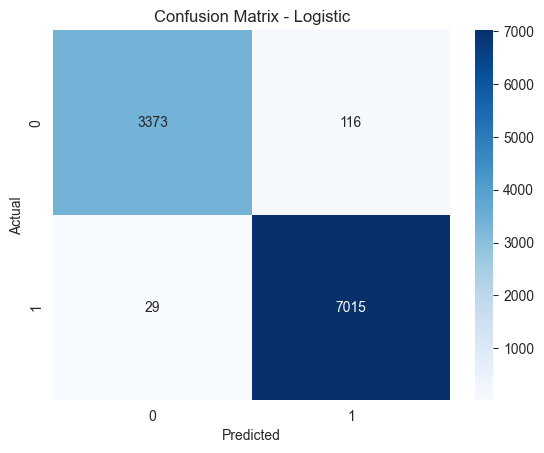


Logistic:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98      3489
           1       0.98      1.00      0.99      7044

    accuracy                           0.99     10533
   macro avg       0.99      0.98      0.98     10533
weighted avg       0.99      0.99      0.99     10533



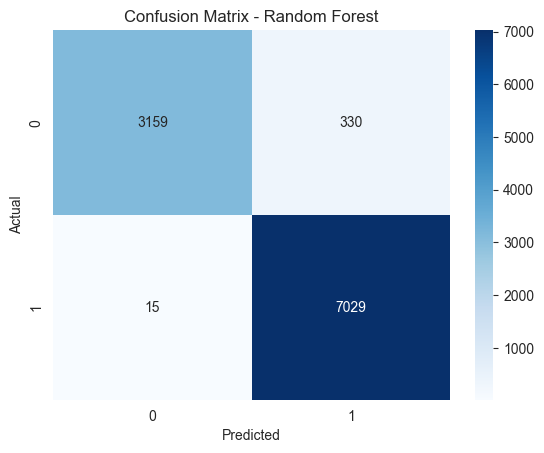


Random Forest:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95      3489
           1       0.96      1.00      0.98      7044

    accuracy                           0.97     10533
   macro avg       0.98      0.95      0.96     10533
weighted avg       0.97      0.97      0.97     10533



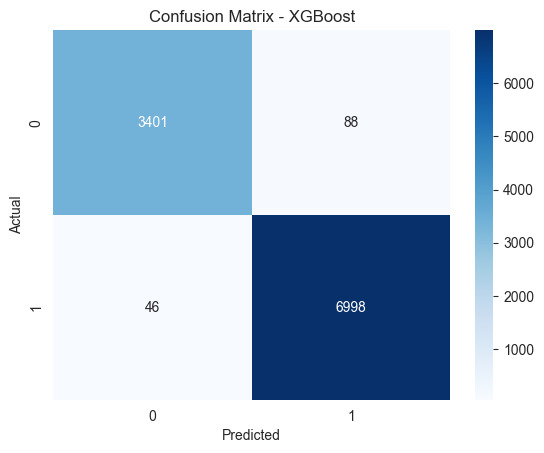


XGBoost:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98      3489
           1       0.99      0.99      0.99      7044

    accuracy                           0.99     10533
   macro avg       0.99      0.98      0.99     10533
weighted avg       0.99      0.99      0.99     10533



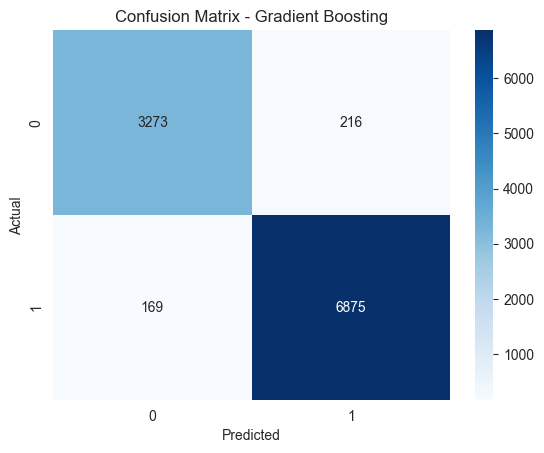


Gradient Boosting:
               precision    recall  f1-score   support

           0       0.95      0.94      0.94      3489
           1       0.97      0.98      0.97      7044

    accuracy                           0.96     10533
   macro avg       0.96      0.96      0.96     10533
weighted avg       0.96      0.96      0.96     10533



In [67]:
for name, model in [("Ridge", model_rr), ("Logistic", model_lr), ("Random Forest", model_rf), ("XGBoost", model_xgb), ("Gradient Boosting", model_gbc) ]:
    y_pred = model.predict(X_val)

    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print(f"\n{name}:\n", classification_report(y_val, y_pred))

In [68]:
df["real"].value_counts(normalize=True)

real
1    0.668724
0    0.331276
Name: proportion, dtype: float64

In [69]:
from sklearn.model_selection import cross_val_score

In [70]:
cv_scores = cross_val_score(model_rr, X_train, y_train, cv=10, scoring="accuracy")

In [71]:
print(cv_scores, cv_scores.mean())

[0.99026822 0.9909803  0.99121766 0.99169238 0.99145502 0.99121766
 0.99454071 0.99145502 0.99050558 0.99287918] 0.9916211725611204


In [72]:
from sklearn.model_selection import cross_validate

In [73]:
scoring = {
    "f1_fake": "f1_macro",
    "f1_weighted": "f1_weighted"
}

In [74]:
scores = cross_validate(model_rr, X_train, y_train, cv=5, scoring=scoring)

In [75]:
print(scores)
print(cv_scores, cv_scores.mean())

{'fit_time': array([0.75664663, 0.77722383, 0.78959322, 0.76109982, 0.76370931]), 'score_time': array([0.01565623, 0.        , 0.        , 0.        , 0.        ]), 'test_f1_fake': array([0.98909011, 0.9896423 , 0.98962308, 0.99165618, 0.99031399]), 'test_f1_weighted': array([0.99035877, 0.99084095, 0.99083311, 0.99262412, 0.99143608])}
[0.99026822 0.9909803  0.99121766 0.99169238 0.99145502 0.99121766
 0.99454071 0.99145502 0.99050558 0.99287918] 0.9916211725611204


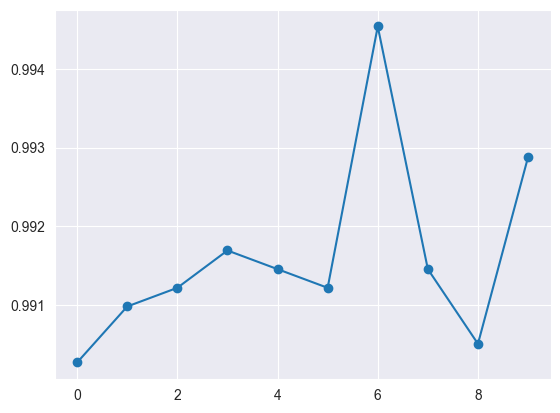

In [76]:
plt.plot(cv_scores, marker="o")

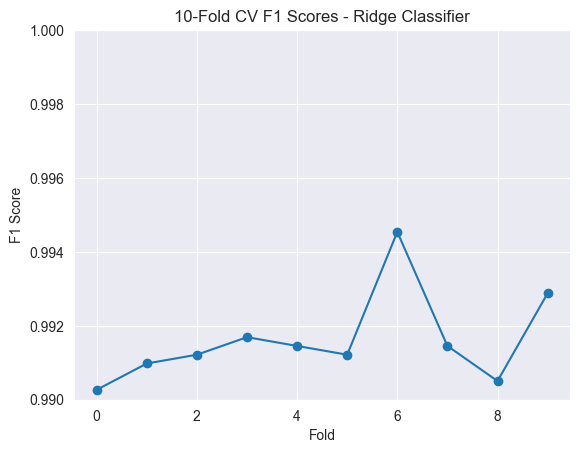

In [77]:
plt.plot(cv_scores, marker='o')
plt.title("10-Fold CV F1 Scores - Ridge Classifier")
plt.ylabel("F1 Score")
plt.xlabel("Fold")
plt.ylim(0.99, 1.0)
plt.grid(True)
plt.show()